# Notebook 03 — Deep Dive: Density-Based Methods
DBSCAN vs HDBSCAN: eps sensitivity, condensed tree, noise analysis.

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import os
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.cluster import DBSCAN

from src.datasets import load_penguins, load_wine_data
from src.diagnostics import plot_kdistance
from src.metrics import compute_all_metrics

CACHE_DIR = '../outputs'
os.makedirs('../outputs/figures', exist_ok=True)

In [2]:
x_pen, y_pen = load_penguins()
x_wine, y_wine = load_wine_data()
print(f'penguins: {x_pen.shape}, wine: {x_wine.shape}')

penguins: (333, 4), wine: (178, 13)


## k-Distance plots — guiding DBSCAN eps

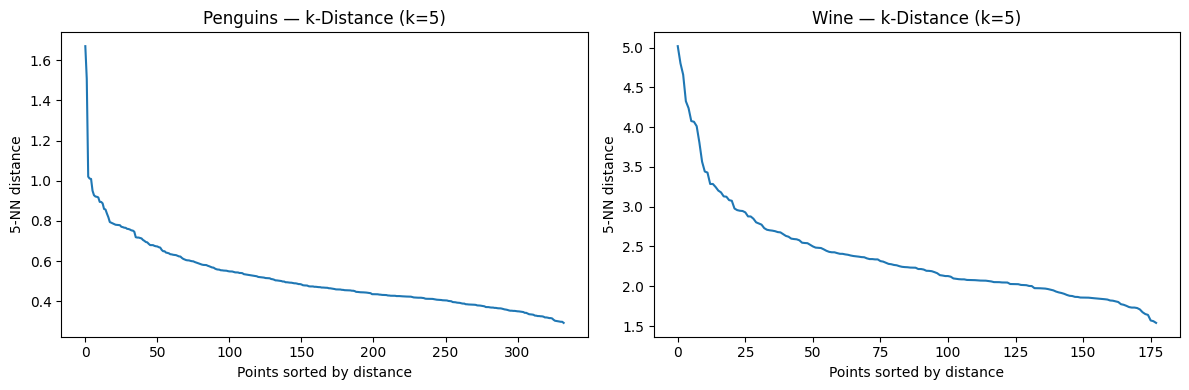

Saved 03_kdistance.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_kdistance(x_pen, k=5, ax=axes[0])
axes[0].set_title('Penguins — k-Distance (k=5)')
plot_kdistance(x_wine, k=5, ax=axes[1])
axes[1].set_title('Wine — k-Distance (k=5)')
plt.tight_layout()
plt.savefig('../outputs/figures/03_kdistance.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved 03_kdistance.png')

## DBSCAN eps sensitivity sweep

In [4]:
eps_values = [0.2, 0.4, 0.6, 0.8, 1.0, 1.5, 2.0]
rows = []
for ds_name, x, y in [('penguins', x_pen, y_pen), ('wine', x_wine, y_wine)]:
    for eps in eps_values:
        labels = DBSCAN(eps=eps, min_samples=5).fit_predict(x)
        n_clusters = len(np.unique(labels[labels >= 0]))
        n_noise = int((labels == -1).sum())
        ari = compute_all_metrics(x, y, labels)['ari']
        rows.append({'dataset': ds_name, 'eps': eps, 'n_clusters': n_clusters, 'n_noise': n_noise, 'ari': ari})

df_eps = pd.DataFrame(rows)
print(df_eps.to_string(index=False))

 dataset  eps  n_clusters  n_noise      ari
penguins  0.2           0      333 0.000000
penguins  0.4          12      169 0.093952
penguins  0.6           2       32 0.579397
penguins  0.8           2        5 0.639770
penguins  1.0           2        1 0.650608
penguins  1.5           1        0 0.000000
penguins  2.0           1        0 0.000000
    wine  0.2           0      178 0.000000
    wine  0.4           0      178 0.000000
    wine  0.6           0      178 0.000000
    wine  0.8           0      178 0.000000
    wine  1.0           0      178 0.000000
    wine  1.5           0      178 0.000000
    wine  2.0           5       85 0.220491


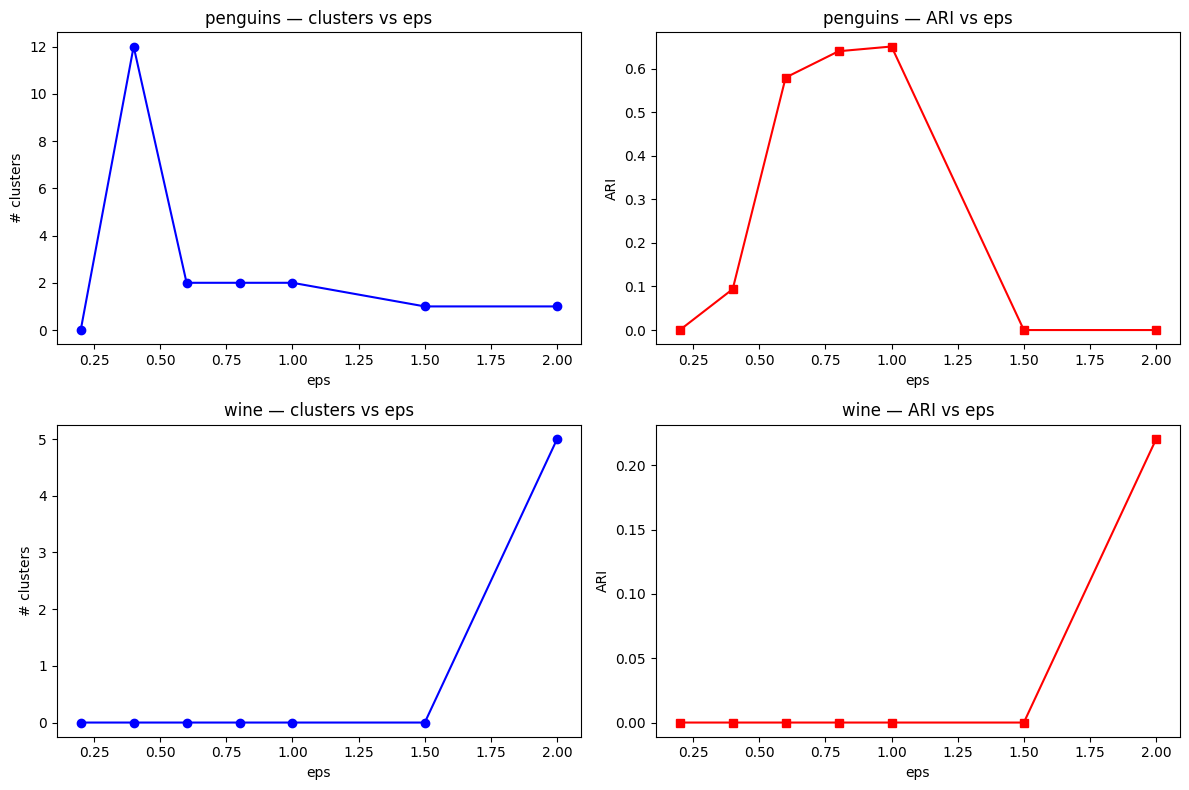

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, ds_name in enumerate(['penguins', 'wine']):
    sub = df_eps[df_eps.dataset == ds_name]
    axes[i, 0].plot(sub.eps, sub.n_clusters, 'bo-')
    axes[i, 0].set_xlabel('eps'); axes[i, 0].set_ylabel('# clusters')
    axes[i, 0].set_title(f'{ds_name} — clusters vs eps')
    axes[i, 1].plot(sub.eps, sub.ari, 'rs-')
    axes[i, 1].set_xlabel('eps'); axes[i, 1].set_ylabel('ARI')
    axes[i, 1].set_title(f'{ds_name} — ARI vs eps')
plt.tight_layout()
plt.savefig('../outputs/figures/03_dbscan_eps_sweep.png', dpi=100, bbox_inches='tight')
plt.show()

## HDBSCAN min_cluster_size sensitivity

In [6]:
mcs_values = [3, 5, 10, 15, 25, 50]
rows_h = []
for ds_name, x, y in [('penguins', x_pen, y_pen), ('wine', x_wine, y_wine)]:
    for mcs in mcs_values:
        labels = HDBSCAN(min_cluster_size=mcs).fit_predict(x)
        n_clusters = len(np.unique(labels[labels >= 0]))
        n_noise = int((labels == -1).sum())
        ari = compute_all_metrics(x, y, labels)['ari']
        rows_h.append({'dataset': ds_name, 'min_cluster_size': mcs, 'n_clusters': n_clusters, 'n_noise': n_noise, 'ari': ari})

df_hdb = pd.DataFrame(rows_h)
print(df_hdb.to_string(index=False))

 dataset  min_cluster_size  n_clusters  n_noise      ari
penguins                 3           2        1 0.650608
penguins                 5           2        2 0.645974
penguins                10           2        2 0.645974
penguins                15           2        3 0.648079
penguins                25           2        8 0.640253
penguins                50           2       60 0.575354
    wine                 3           2       48 0.376854
    wine                 5           2       70 0.265957
    wine                10           2       82 0.232853
    wine                15           2       86 0.209679
    wine                25           0      178 0.000000
    wine                50           0      178 0.000000


## HDBSCAN condensed tree (penguins)

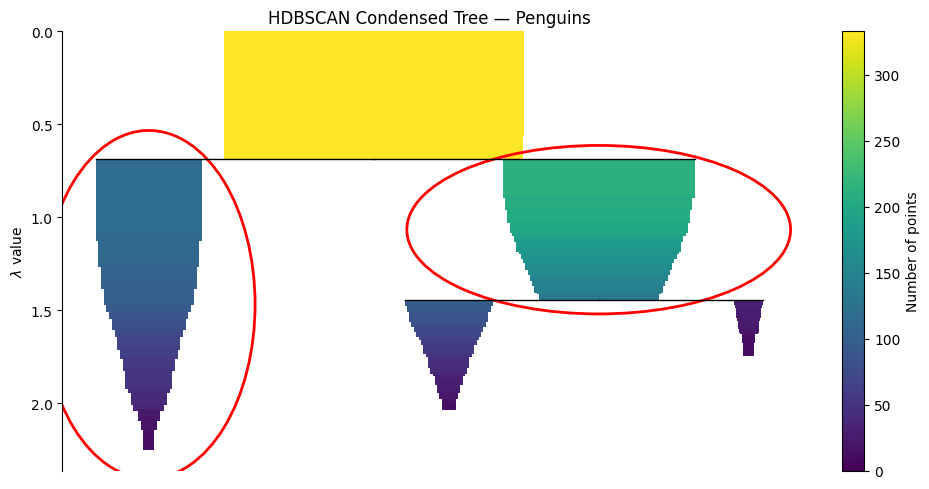

Saved 03_hdbscan_tree.png


In [7]:
hdb = HDBSCAN(min_cluster_size=10, gen_min_span_tree=True)
hdb.fit(x_pen)
fig, ax = plt.subplots(figsize=(10, 5))
hdb.condensed_tree_.plot(select_clusters=True, axis=ax)
ax.set_title('HDBSCAN Condensed Tree — Penguins')
plt.tight_layout()
plt.savefig('../outputs/figures/03_hdbscan_tree.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved 03_hdbscan_tree.png')

## DBSCAN vs HDBSCAN side-by-side on penguins (UMAP)

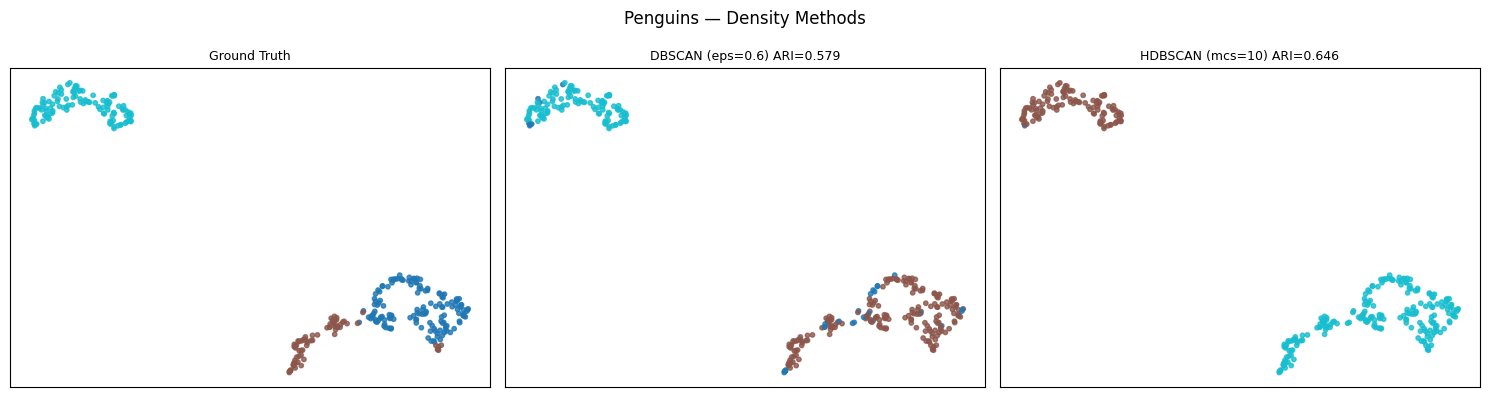

In [8]:
cache = f'{CACHE_DIR}/umap_penguins.pkl'
if os.path.exists(cache):
    emb = joblib.load(cache)
else:
    emb = UMAP(n_neighbors=15, min_dist=0.1, random_state=42, n_jobs=2).fit_transform(x_pen)
    joblib.dump(emb, cache)

labels_db = DBSCAN(eps=0.6, min_samples=5).fit_predict(x_pen)
labels_hdb = HDBSCAN(min_cluster_size=10).fit_predict(x_pen)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (title, labels) in zip(axes, [
    ('Ground Truth', y_pen),
    (f'DBSCAN (eps=0.6) ARI={compute_all_metrics(x_pen, y_pen, labels_db)["ari"]:.3f}', labels_db),
    (f'HDBSCAN (mcs=10) ARI={compute_all_metrics(x_pen, y_pen, labels_hdb)["ari"]:.3f}', labels_hdb),
]):
    ax.scatter(emb[:, 0], emb[:, 1], c=labels, cmap='tab10', s=10, alpha=0.8)
    ax.set_title(title, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle('Penguins — Density Methods', fontsize=12)
plt.tight_layout()
plt.savefig('../outputs/figures/03_density_comparison.png', dpi=100, bbox_inches='tight')
plt.show()